In [1]:
import os
import numpy as np
from util import *
import random
import gc
import tensorflow as tf
from tensorflow.keras import layers, models, Model, Input
import copy as c
import pickle
from keras.models import load_model
import json
from sklearn.metrics import precision_recall_curve, log_loss, auc, precision_score, recall_score, f1_score
from scipy.signal import argrelextrema
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
from tabulate import tabulate

[   INFO   ] MusicExtractorSVM: no classifier models were configured by default
I0000 00:00:1782837366.390738  553196 cpu_feature_guard.cc:227] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.


In [2]:
batch_size = 32
max_chunk_size = 1000
classification_scheme = 'multilabel'
memlen = 15
nframes = 32
nmelbands = 80
nchannels = 3
name_from_fp = lambda x: os.path.splitext(os.path.split(x)[1])[0]

onset_model = load_model('trained_models/onset_model.keras')
onset_model_ddc = load_model('trained_models/onset_ddc_model.keras')
#onset_model_conv3d = load_model('trained_models/onset_conv3d_model.keras')
#onset_model_bidirectional = load_model('trained_models/onset_bidirectional_model.keras')

lbl_fp = 'onset/songs/stream_labels.pkl'
vld_fp = 'onset/songs/songs_valid.txt'
json_fp = 'json/songs/songs_valid.txt'

ddc_memlen = 100
context_radius = 7
ddc_npred_steps = 5
ddc_tolerance = 2
ddc_removal_order = [1,-1,2,-2,3,-3]
feats_dir = 'feats/songs'
diff_dict = {
    'Beginner': 0,
    'Easy': 1,
    'Medium': 2,
    'Hard': 3,
    'Edit': 4,
    'Challenge': 4
}
metrics = ['f1_coarse', 'f1_fine', 'f1_avg',
           'max_f1_coarse', 'max_f1_fine', 'max_f1_avg',
           'auc_coarse', 'auc_fine',
           'prec_coarse', 'prec_fine', 'prec_avg',
           'max_prec_coarse', 'max_prec_fine', 'max_prec_avg',
           'recall_coarse', 'recall_fine', 'recall_avg',
           'max_recall_coarse', 'max_recall_fine', 'max_recall_avg',
           'log_loss_coarse', 'log_loss_fine', 
           'max_thresh_coarse', 'max_thresh_fine', 'max_thresh_avg']

I0000 00:00:1782837370.492016  553196 gpu_device.cc:2043] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 5154 MB memory:  -> device: 0, name: NVIDIA GeForce RTX 3080, pci bus id: 0000:05:00.0, compute capability: 8.6


In [5]:
onset_model_ddc.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-4),
    loss=tf.keras.losses.BinaryCrossentropy(from_logits = False),
    metrics=[
        tf.keras.metrics.BinaryAccuracy()
],
)
onset_model_ddc.summary()

metric_dict = {name: dict() for name in metrics}

tp = 0
fp = 0
fn = 0
mtp = 0
mfp = 0
mfn = 0
threshlist = []

with open(json_fp, 'r') as f:
    json_fps = f.read().splitlines()
    json_fps = list(np.unique(json_fps))
for fpt in json_fps:
    with open(fpt, 'r') as json_f:
        meta = json.loads(json_f.read())
    json_name = name_from_fp(fpt)
    song_feats_fp = os.path.join(feats_dir, '{}.pkl'.format(json_name))
    with open(song_feats_fp, 'rb') as f:
        song_feats = pickle.load(f)

    diffs_done = []
    for chart in meta['charts']:
        if chart['type'] == 'dance-double':
            continue
        diff_coarse = diff_dict[chart['difficulty_coarse']]
        diff_fine = chart['difficulty_fine']
        if diff_fine in diffs_done:
            continue
        else:
            diffs_done.append(diff_fine)
        
        
        placed_notes = np.zeros(len(song_feats))
        for note in chart['notes']:
            if note[3] != '0000':
                placed_notes[int(round(note[2]*100))] = 1

        chart_diff_feed = [[[diff_coarse] for _ in range(ddc_memlen+ddc_npred_steps-1)] for _ in range(0,len(song_feats),ddc_npred_steps)]
        song_feed = [make_onset_feature_context(song_feats, i, radius = 3+ddc_npred_steps, left_radius = ddc_memlen+3) for i in range(0,len(song_feats),ddc_npred_steps)]
        assert len(song_feed) == len(chart_diff_feed)

        scores = onset_model_ddc.predict((np.array(song_feed), np.array(chart_diff_feed)), batch_size = 256)
        scores = scores.flatten()
        placed_notes = placed_notes[:len(scores)]
        scores = scores[:len(placed_notes)]
        scores = np.convolve(scores, np.hamming(5), mode = 'same')
        maxima = list(argrelextrema(scores, np.greater_equal, order = 1)[0])
        n_scores = np.zeros_like(scores)
        for maxi in maxima:
            n_scores[maxi] = scores[maxi]
        scores = n_scores
        
        for l in range(ddc_tolerance):
            for j in range(len(scores)):
                if placed_notes[j]==1 and scores[j] == 0:
                    for m in ddc_removal_order[2*l:(2*l)+2]:
                        if placed_notes[j+m]!=1 and scores[j+m] > 0:
                            scores[j] = c.deepcopy(scores[j+m])
                            scores[j+m] = 0
                            break
        
        prec, rec, threshes = precision_recall_curve(placed_notes, scores)
        AUC = auc(rec,prec)
        loss = log_loss(placed_notes, scores)

        fd = prec + rec
        fd[np.where(fd == 0)] = 1
        fs = (2*(prec*rec))/fd
        MID = np.argmax(fs)
        MaxF1, MaxPrec, MaxRec, MaxThresh = fs[MID], prec[MID], rec[MID], threshes[MID]
        threshlist.append(MaxThresh)

        mtp += np.sum((scores >= MaxThresh) & (placed_notes == 1))
        mfp += np.sum((scores >= MaxThresh) & (placed_notes == 0))
        mfn += np.sum((scores < MaxThresh) & (placed_notes == 1))
                
        chart_tp = np.sum((scores >= 0.5) & (placed_notes== 1))
        chart_fp = np.sum((scores >= 0.5) & (placed_notes == 0))
        chart_fn = np.sum((scores < 0.5) & (placed_notes == 1))
        
        # Global accumulation trackers
        tp += chart_tp
        fp += chart_fp
        fn += chart_fn

        # Calculate exact chart-level metrics via the counting method
        F1 = chart_tp / (chart_tp + 0.5 * (chart_fp + chart_fn)) if (chart_tp + chart_fp + chart_fn) > 0 else 0
        Prec = chart_tp / (chart_tp + chart_fp) if (chart_tp + chart_fp) > 0 else 0
        Recall = chart_tp / (chart_tp + chart_fn) if (chart_tp + chart_fn) > 0 else 0
            
        out_met = {'log_loss': loss, 'f1': F1, 'auc': AUC, 
                   'prec': Prec, 'recall': Recall, 
                   'max_f1': MaxF1, 'max_prec': MaxPrec, 'max_recall': MaxRec, 'max_thresh': MaxThresh}
        for k,v in out_met.items():
            kc = k + '_coarse'
            kf = k + '_fine'
            if diff_coarse in metric_dict[kc]:
                metric_dict[kc][diff_coarse].append(v)
            else:
                metric_dict[kc][diff_coarse] = [v]
            if diff_fine in metric_dict[kf]:
                metric_dict[kf][diff_fine].append(v)
            else:
                metric_dict[kf][diff_fine] = [v]
                
F1 = tp/(tp+.5*(fp+fn))
Prec = tp/(tp+fp)
Recall = tp/(tp+fn)   
MaxF1 = mtp/(mtp+.5*(mfp+mfn))
MaxPrec = mtp/(mtp+mfp)
MaxRecall = mtp/(mtp+mfn)
MaxThresh = np.median(threshlist)
metric_dict['f1_avg'] = F1
metric_dict['prec_avg'] = Prec
metric_dict['recall_avg'] = Recall
metric_dict['max_f1_avg'] = MaxF1
metric_dict['max_prec_avg'] = MaxPrec
metric_dict['max_recall_avg'] = MaxRecall
metric_dict['max_thresh_avg'] = MaxThresh
print(f'f1 avg: {F1}')
print(f'Prec avg: {Prec}')
print(f'Recall avg: {Recall}')
print(f'Max f1 avg: {MaxF1}')
print(f'Max Prec avg: {MaxPrec}')
print(f'Max Recall avg: {MaxRecall}')
print(f'Max Thresh median: {MaxThresh}')
metric_dict_ddc = metric_dict

Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer         │ (256, 112, 80, 3) │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalization │ (256, 112, 80, 3) │         12 │ input_layer[0][0] │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d (Conv2D)     │ (256, 106, 78,    │        640 │ batch_normalizat… │
│                     │ 10)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d       │ (256, 106, 26,    │          0 │ conv2d[0][0]      │
│ (MaxPooling2D)      │ 10)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_1 (Conv2D)   │ (256, 104, 24,    │      1,820 │ max_pooling2d[0]… │
│                     │ 20)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d_1     │ (256, 104, 8, 20) │          0 │ conv2d_1[0][0]    │
│ (MaxPooling2D)      │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ reshape (Reshape)   │ (256, 104, 160)   │          0 │ max_pooling2d_1[… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ input_layer_1       │ (256, 104, 1)     │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ concatenate         │ (256, 104, 161)   │          0 │ reshape[0][0],    │
│ (Concatenate)       │                   │            │ input_layer_1[0]… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ lstm (LSTM)         │ (256, 104, 200)   │    289,600 │ concatenate[0][0] │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ lstm_1 (LSTM)       │ (256, 200)        │    320,800 │ lstm[0][0]        │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense (Dense)       │ (256, 256)        │     51,456 │ lstm_1[0][0]      │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_1 (Dense)     │ (256, 128)        │     32,896 │ dense[0][0]       │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_2 (Dense)     │ (256, 5)          │        645 │ dense_1[0][0]     │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 697,869 (2.66 MB)

 Trainable params: 697,863 (2.66 MB)

 Non-trainable params: 6 (24.00 B)

11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 27ms/step
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 33ms/step
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step
14/14 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step
14/14 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step
14/14 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step
14/14 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step
14/14 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 30ms/step
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step


In [4]:
onset_model_ddc.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-4),
    loss=tf.keras.losses.BinaryCrossentropy(from_logits = False),
    metrics=[
        tf.keras.metrics.BinaryAccuracy()
],
)
#onset_model_ddc.summary()

metric_dict = {name: dict() for name in metrics}

tp = 0
fp = 0
fn = 0
mtp = 0
mfp = 0
mfn = 0
threshlist = []

with open(json_fp, 'r') as f:
    json_fps = f.read().splitlines()
    json_fps = list(np.unique(json_fps))
for fpt in json_fps:
    with open(fpt, 'r') as json_f:
        meta = json.loads(json_f.read())
    json_name = name_from_fp(fpt)
    song_feats_fp = os.path.join(feats_dir, '{}.pkl'.format(json_name))
    with open(song_feats_fp, 'rb') as f:
        song_feats = pickle.load(f)

    diffs_done = []
    for chart in meta['charts']:
        if chart['type'] == 'dance-double':
            continue
        diff_coarse = diff_dict[chart['difficulty_coarse']]
        diff_fine = chart['difficulty_fine']
        if diff_fine in diffs_done:
            continue
        else:
            diffs_done.append(diff_fine)
        
        
        placed_notes = np.zeros(len(song_feats))
        for note in chart['notes']:
            if note[3] != '0000':
                placed_notes[int(round(note[2]*100))] = 1

        chart_diff_feed = [[[diff_coarse] for _ in range(ddc_memlen+ddc_npred_steps-1)] for _ in range(0,len(song_feats),ddc_npred_steps)]
        song_feed = [make_onset_feature_context(song_feats, i, radius = 3+ddc_npred_steps, left_radius = ddc_memlen+3) for i in range(0,len(song_feats),ddc_npred_steps)]
        assert len(song_feed) == len(chart_diff_feed)

        scores = onset_model_ddc.predict((np.array(song_feed), np.array(chart_diff_feed)), batch_size = 256)
        scores = scores.flatten()
        placed_notes = placed_notes[:len(scores)]
        scores = scores[:len(placed_notes)]
        scores = np.convolve(scores, np.hamming(5), mode = 'same')
        maxima = list(argrelextrema(scores, np.greater_equal, order = 1)[0])
        n_scores = np.zeros_like(scores)
        for maxi in maxima:
            n_scores[maxi] = scores[maxi]
        scores = n_scores
        
        for l in range(1):
            for j in range(len(scores)):
                if placed_notes[j]==1 and scores[j] == 0:
                    for m in ddc_removal_order[2*l:(2*l)+2]:
                        if placed_notes[j+m]!=1 and scores[j+m] > 0:
                            scores[j] = c.deepcopy(scores[j+m])
                            scores[j+m] = 0
                            break
        
        prec, rec, threshes = precision_recall_curve(placed_notes, scores)
        AUC = auc(rec,prec)
        loss = log_loss(placed_notes, scores)

        fd = prec + rec
        fd[np.where(fd == 0)] = 1
        fs = (2*(prec*rec))/fd
        MID = np.argmax(fs)
        MaxF1, MaxPrec, MaxRec, MaxThresh = fs[MID], prec[MID], rec[MID], threshes[MID]
        threshlist.append(MaxThresh)
        
        mtp += np.sum((scores >= MaxThresh) & (placed_notes == 1))
        mfp += np.sum((scores >= MaxThresh) & (placed_notes == 0))
        mfn += np.sum((scores < MaxThresh) & (placed_notes == 1))
                
        chart_tp = np.sum((scores >= 0.5) & (placed_notes== 1))
        chart_fp = np.sum((scores >= 0.5) & (placed_notes == 0))
        chart_fn = np.sum((scores < 0.5) & (placed_notes == 1))
        
        # Global accumulation trackers
        tp += chart_tp
        fp += chart_fp
        fn += chart_fn

        # Calculate exact chart-level metrics via the counting method
        F1 = chart_tp / (chart_tp + 0.5 * (chart_fp + chart_fn)) if (chart_tp + chart_fp + chart_fn) > 0 else 0
        Prec = chart_tp / (chart_tp + chart_fp) if (chart_tp + chart_fp) > 0 else 0
        Recall = chart_tp / (chart_tp + chart_fn) if (chart_tp + chart_fn) > 0 else 0
            
        out_met = {'log_loss': loss, 'f1': F1, 'auc': AUC, 
                   'prec': Prec, 'recall': Recall, 
                   'max_f1': MaxF1, 'max_prec': MaxPrec, 'max_recall': MaxRec, 'max_thresh': MaxThresh}
        for k,v in out_met.items():
            kc = k + '_coarse'
            kf = k + '_fine'
            if diff_coarse in metric_dict[kc]:
                metric_dict[kc][diff_coarse].append(v)
            else:
                metric_dict[kc][diff_coarse] = [v]
            if diff_fine in metric_dict[kf]:
                metric_dict[kf][diff_fine].append(v)
            else:
                metric_dict[kf][diff_fine] = [v]
                
F1 = tp/(tp+.5*(fp+fn))
Prec = tp/(tp+fp)
Recall = tp/(tp+fn)   
MaxF1 = mtp/(mtp+.5*(mfp+mfn))
MaxPrec = mtp/(mtp+mfp)
MaxRecall = mtp/(mtp+mfn)
MaxThresh = np.median(threshlist)
metric_dict['f1_avg'] = F1
metric_dict['prec_avg'] = Prec
metric_dict['recall_avg'] = Recall
metric_dict['max_f1_avg'] = MaxF1
metric_dict['max_prec_avg'] = MaxPrec
metric_dict['max_recall_avg'] = MaxRecall
metric_dict['max_thresh_avg'] = MaxThresh
print(f'f1 avg: {F1}')
print(f'Prec avg: {Prec}')
print(f'Recall avg: {Recall}')
print(f'Max f1 avg: {MaxF1}')
print(f'Max Prec avg: {MaxPrec}')
print(f'Max Recall avg: {MaxRecall}')
print(f'Max Thresh median: {MaxThresh}')
metric_dict_ddc_t1 = metric_dict

11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 25ms/step
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step
14/14 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step
14/14 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step
14/14 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step
14/14 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step
14/14 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step


In [6]:
metric_dict = {name: dict() for name in metrics}

vld_ds = get_dataset_fp_list(vld_fp)

tp, fp, fn = 0, 0, 0
mtp, mfp, mfn = 0, 0, 0
threshlist = []

with open(lbl_fp, 'rb') as f:
    labels = pickle.load(f)
enc_dict = label_to_vect_dict(labels, force_max_len=48)

# 2. Sequential Validation Pass over the dataset
for fpt in vld_ds:
    with open(fpt, 'rb') as f:
        charts = pickle.load(f)
        
    feats_fp = charts[3]  # Extract independent feature reference path
    with open(feats_fp, 'rb') as f:
        feats = pickle.load(f)
        
    # Step through every chart variant contained inside this entry
    for j in range(len(charts[0])):
        chart = [charts[i][j] for i in range(3)]
        
        diff_coarse = diff_dict[chart[1][0][-1]]
        diff_fine = chart[1][0][0]

        # Resolve features from external file via window context ranges
        chart[0] = [make_onset_feature_context_range(feats, x[0], x[1]) for x in chart[0]]
        
        # Standardize features
        mean = np.mean(chart[0], axis=0)
        std = np.std(chart[0], axis=0)
        chart[0] = (np.array(chart[0]) - mean) / (std + 1e-7)
        
        chart[1] = [[a[0], a[1]] for a in chart[1]]
        placed_notes = np.array([enc_dict[i] for i in chart[2]])

        # Window chunking evaluation setup
        full_take_windows = range(len(chart[0]))
        scores = []
        
        # Windowize and infer in structured batches to avoid out-of-memory errors
        for i in range(0, len(chart[0]), max_chunk_size):
            cut_chart = [[], [], []]
            take_windows = full_take_windows[i:min(i + max_chunk_size, len(full_take_windows))]
            
            # Recreate identical windowize configuration seen in generatorify
            cut_chart.append(windowize(chart[0], front_set='min', go_backwards=True, frames=memlen, take_windows=take_windows, return_type='list'))
            cut_chart[0] = windowize(chart[0], front_set='min', frames=memlen, take_windows=take_windows, return_type='list')
            cut_chart.append(windowize(chart[1], go_backwards=True, frames=memlen, take_windows=take_windows, return_type='list'))
            cut_chart[1] = windowize(chart[1], frames=memlen, take_windows=take_windows, return_type='list')
            
            # Predict
            cut_scores = onset_model.predict((
                np.array(cut_chart[0]),
                np.array(cut_chart[3]),
                np.array(cut_chart[1]),
                np.flip(np.array(cut_chart[4]), 1)
            ), batch_size=batch_size, verbose=1)
            
            scores.extend(cut_scores)
            del cut_chart
            
        scores = np.array(scores)
        
        # 3. Micro-level Multi-Label Metrics Extraction
        # Reshape or flatten safely matching both 48-output target profiles 
        flat_placed = placed_notes.flatten()
        flat_scores = scores.flatten()
        
        prec, rec, threshes = precision_recall_curve(flat_placed, flat_scores)
        AUC = auc(rec, prec)
        loss = log_loss(flat_placed, flat_scores)
        
        fd = prec + rec
        fd[np.where(fd == 0)] = 1
        fs = (2 * (prec * rec)) / fd
        MID = np.argmax(fs)
        
        MaxF1, MaxPrec, MaxRec, MaxThresh = fs[MID], prec[MID], rec[MID], threshes[MID]
        threshlist.append(MaxThresh)
        
        # Accumulate metrics
        mtp += np.sum((flat_scores >= MaxThresh) & (flat_placed == 1))
        mfp += np.sum((flat_scores >= MaxThresh) & (flat_placed == 0))
        mfn += np.sum((flat_scores < MaxThresh) & (flat_placed == 1))

        chart_tp = np.sum((flat_scores >= 0.5) & (flat_placed == 1))
        chart_fp = np.sum((flat_scores >= 0.5) & (flat_placed == 0))
        chart_fn = np.sum((flat_scores < 0.5) & (flat_placed == 1))
        
        # Global accumulation trackers
        tp += chart_tp
        fp += chart_fp
        fn += chart_fn

        # Calculate exact chart-level metrics via the counting method
        F1 = chart_tp / (chart_tp + 0.5 * (chart_fp + chart_fn)) if (chart_tp + chart_fp + chart_fn) > 0 else 0
        Prec = chart_tp / (chart_tp + chart_fp) if (chart_tp + chart_fp) > 0 else 0
        Recall = chart_tp / (chart_tp + chart_fn) if (chart_tp + chart_fn) > 0 else 0
        out_met = {
            'log_loss': loss, 'f1': F1, 'auc': AUC, 'prec': Prec, 'recall': Recall, 
            'max_f1': MaxF1, 'max_prec': MaxPrec, 'max_recall': MaxRec, 'max_thresh': MaxThresh
        }
        
        # Populate categorized nested dictionaries
        for k, v in out_met.items():
            for categorization, diff_key in [('_coarse', diff_coarse), ('_fine', diff_fine)]:
                kc = k + categorization
                if diff_key in metric_dict[kc]:
                    metric_dict[kc][diff_key].append(v)
                else:
                    metric_dict[kc][diff_key] = [v]
                    
    del feats, charts
    gc.collect()

F1 = tp/(tp+.5*(fp+fn))
Prec = tp/(tp+fp)
Recall = tp/(tp+fn)   
MaxF1 = mtp/(mtp+.5*(mfp+mfn))
MaxPrec = mtp/(mtp+mfp)
MaxRecall = mtp/(mtp+mfn)
MaxThresh = np.median(threshlist)
metric_dict['f1_avg'] = F1
metric_dict['prec_avg'] = Prec
metric_dict['recall_avg'] = Recall
metric_dict['max_f1_avg'] = MaxF1
metric_dict['max_prec_avg'] = MaxPrec
metric_dict['max_recall_avg'] = MaxRecall
metric_dict['max_thresh_avg'] = MaxThresh
print(f'f1 avg: {F1}')
print(f'Prec avg: {Prec}')
print(f'Recall avg: {Recall}')
print(f'Max f1 avg: {MaxF1}')
print(f'Max Prec avg: {MaxPrec}')
print(f'Max Recall avg: {MaxRecall}')
print(f'Max Thresh median: {MaxThresh}')
metric_dict_ddcl = metric_dict

12/12 ━━━━━━━━━━━━━━━━━━━━ 3s 146ms/step
12/12 ━━━━━━━━━━━━━━━━━━━━ 1s 90ms/step
12/12 ━━━━━━━━━━━━━━━━━━━━ 1s 74ms/step
12/12 ━━━━━━━━━━━━━━━━━━━━ 1s 73ms/step
12/12 ━━━━━━━━━━━━━━━━━━━━ 1s 77ms/step
12/12 ━━━━━━━━━━━━━━━━━━━━ 1s 77ms/step
10/10 ━━━━━━━━━━━━━━━━━━━━ 1s 95ms/step
10/10 ━━━━━━━━━━━━━━━━━━━━ 1s 90ms/step
10/10 ━━━━━━━━━━━━━━━━━━━━ 1s 72ms/step
10/10 ━━━━━━━━━━━━━━━━━━━━ 1s 73ms/step
10/10 ━━━━━━━━━━━━━━━━━━━━ 1s 75ms/step
11/11 ━━━━━━━━━━━━━━━━━━━━ 1s 97ms/step
11/11 ━━━━━━━━━━━━━━━━━━━━ 1s 93ms/step
11/11 ━━━━━━━━━━━━━━━━━━━━ 1s 96ms/step
11/11 ━━━━━━━━━━━━━━━━━━━━ 1s 78ms/step
11/11 ━━━━━━━━━━━━━━━━━━━━ 1s 78ms/step
8/8 ━━━━━━━━━━━━━━━━━━━━ 1s 80ms/step
8/8 ━━━━━━━━━━━━━━━━━━━━ 1s 81ms/step
8/8 ━━━━━━━━━━━━━━━━━━━━ 1s 80ms/step
8/8 ━━━━━━━━━━━━━━━━━━━━ 1s 80ms/step
8/8 ━━━━━━━━━━━━━━━━━━━━ 1s 79ms/step
8/8 ━━━━━━━━━━━━━━━━━━━━ 1s 103ms/step
16/16 ━━━━━━━━━━━━━━━━━━━━ 2s 92ms/step
16/16 ━━━━━━━━━━━━━━━━━━━━ 1s 77ms/step
16/16 ━━━━━━━━━━━━━━━━━━━━ 1s 88ms/step
16/16 ━━━━

In [11]:
onset_model_conv3d.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-4),
    loss=tf.keras.losses.BinaryCrossentropy(from_logits = False),
    metrics=[
        tf.keras.metrics.F1Score(average = 'micro', threshold = .5, name = 'f1'),
        tf.keras.metrics.AUC(curve = 'PR', name = 'auc'),
        tf.keras.metrics.Precision(thresholds = 0.5),
        tf.keras.metrics.Recall(thresholds = 0.5),
        tf.keras.metrics.TruePositives(thresholds = 0.5),
        tf.keras.metrics.FalsePositives(thresholds = 0.5),
        tf.keras.metrics.FalseNegatives(thresholds = 0.5)
    ],
)
metric_dict = {name: dict() for name in metrics}

vld_ds = get_dataset_fp_list(vld_fp)
with open(lbl_fp, 'rb') as f:
    labels = pickle.load(f)
enc_dict = label_to_vect_dict(labels)
tp = 0
fp = 0
fn = 0
mtp = 0
mfp = 0
mfn = 0
threshlist = []
for fpt in vld_ds:
    with open(fpt, 'rb') as f:
        charts = pickle.load(f)
    charts = [[charts[i][j] for i in range(3)] for j in range(len(charts[0]))]
    for chart in charts:
        diff_coarse = diff_dict[chart[1][0][-1]]
        diff_fine = chart[1][0][0]

        mean = np.mean(chart[0], axis = 0)
        std = np.std(chart[0], axis = 0)
        chart[0] = (np.array(chart[0])-mean)/std
        
        chart[1] = [[a[0],a[1]] for a in chart[1]]
        chart[2] = np.array([enc_dict[i] for i in chart[2]])
        chart.append(windowize(chart[0], front_set = 'min', go_backwards = True, frames = memlen))
        chart[0] = windowize(chart[0], front_set = 'min', frames = memlen)
        chart.append(windowize(chart[1], go_backwards = True, frames = memlen))
        chart[1] = windowize(chart[1], frames = memlen)
        chart[0] = np.array([np.concatenate((chart[0][j],chart[3][j][1:]), axis = 0) for j in range(len(chart[0]))])
        chart[1] = np.array([np.concatenate((chart[1][j],chart[4][j][1:]), axis = 0) for j in range(len(chart[1]))])
        
        scores = onset_model_conv3d.predict((np.array(chart[0]),np.array(chart[1])))
        
        scores = scores.flatten()
        placed_notes = chart[2].flatten()
        prec, rec, threshes = precision_recall_curve(placed_notes, scores)
        AUC = auc(rec,prec)
        loss = log_loss(placed_notes, scores)
        fd = prec + rec
        fd[np.where(fd == 0)] = 1
        fs = (2*(prec*rec))/fd
        MID = np.argmax(fs)
        MaxF1, MaxPrec, MaxRec, MaxThresh = fs[MID], prec[MID], rec[MID], threshes[MID]
        threshlist.append(MaxThresh)

        mtp += np.sum((scores >= MaxThresh) & (placed_notes == 1))
        mfp += np.sum((scores >= MaxThresh) & (placed_notes == 0))
        mfn += np.sum((scores < MaxThresh) & (placed_notes == 1))

        output = (scores > 0.5)
        F1 = f1_score(placed_notes, output)
        Prec = precision_score(placed_notes, output)
        Recall = recall_score(placed_notes, output)
        tp += np.sum((scores >= .5) & (placed_notes == 1))
        fp += np.sum((scores >= .5) & (placed_notes == 0))
        fn += np.sum((scores < .5) & (placed_notes == 1))

        out_met = {'log_loss': loss, 'f1': F1, 'auc': AUC, 
                   'prec': Prec, 'recall': Recall, 
                   'max_f1': MaxF1, 'max_prec': MaxPrec, 'max_recall': MaxRec, 'max_thresh': MaxThresh}
        for k,v in out_met.items():
            kc = k + '_coarse'
            kf = k + '_fine'
            if diff_coarse in metric_dict[kc]:
                metric_dict[kc][diff_coarse].append(v)
            else:
                metric_dict[kc][diff_coarse] = [v]
            if diff_fine in metric_dict[kf]:
                metric_dict[kf][diff_fine].append(v)
            else:
                metric_dict[kf][diff_fine] = [v]
                
F1 = tp/(tp+.5*(fp+fn))
Prec = tp/(tp+fp)
Recall = tp/(tp+fn)   
MaxF1 = mtp/(mtp+.5*(mfp+mfn))
MaxPrec = mtp/(mtp+mfp)
MaxRecall = mtp/(mtp+mfn)
MaxThresh = np.median(threshlist)
metric_dict['f1_avg'] = F1
metric_dict['prec_avg'] = Prec
metric_dict['recall_avg'] = Recall
metric_dict['max_f1_avg'] = MaxF1
metric_dict['max_prec_avg'] = MaxPrec
metric_dict['max_recall_avg'] = MaxRecall
metric_dict['max_thresh_avg'] = MaxThresh
print(f'f1 avg: {F1}')
print(f'Prec avg: {Prec}')
print(f'Recall avg: {Recall}')
print(f'Max f1 avg: {MaxF1}')
print(f'Max Prec avg: {MaxPrec}')
print(f'Max Recall avg: {MaxRecall}')
print(f'Max Thresh median: {MaxThresh}')
metric_dict_onset_conv3d = metric_dict

12/12 ━━━━━━━━━━━━━━━━━━━━ 1s 59ms/step
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 37ms/step
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 22ms/step
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 38ms/step
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 25ms/step
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step
11/11 ━━━━━━━━━━━━━━━━━━━━ 1s 53ms/step
11/11 ━━━━━━━━━━━━━━━━━━━━ 1s 48ms/step
11/11 ━━━━━━━━━━━━━━━━━━━━ 1s 46ms/step
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 44ms/step
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step
12/12 ━━━━━━

In [12]:
onset_model_bidirectional.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-4),
    loss=tf.keras.losses.BinaryCrossentropy(from_logits = False),
    metrics=[
        tf.keras.metrics.F1Score(average = 'micro', threshold = .5, name = 'f1'),
        tf.keras.metrics.AUC(curve = 'PR', name = 'auc'),
        tf.keras.metrics.Precision(thresholds = 0.5),
        tf.keras.metrics.Recall(thresholds = 0.5),
        tf.keras.metrics.TruePositives(thresholds = 0.5),
        tf.keras.metrics.FalsePositives(thresholds = 0.5),
        tf.keras.metrics.FalseNegatives(thresholds = 0.5)
    ],
)
metric_dict = {name: dict() for name in metrics}

vld_ds = get_dataset_fp_list(vld_fp)
with open(lbl_fp, 'rb') as f:
    labels = pickle.load(f)
enc_dict = label_to_vect_dict(labels)
tp = 0
fp = 0
fn = 0
mtp = 0
mfp = 0
mfn = 0
threshlist = []
for fpt in vld_ds:
    with open(fpt, 'rb') as f:
        charts = pickle.load(f)
    charts = [[charts[i][j] for i in range(3)] for j in range(len(charts[0]))]
    for chart in charts:
        diff_coarse = diff_dict[chart[1][0][-1]]
        diff_fine = chart[1][0][0]

        mean = np.mean(chart[0], axis = 0)
        std = np.std(chart[0], axis = 0)
        chart[0] = (np.array(chart[0])-mean)/std
        
        chart[1] = [[a[0],a[1]] for a in chart[1]]
        chart[2] = np.array([enc_dict[i] for i in chart[2]])
        chart.append(windowize(chart[0], front_set = 'min', go_backwards = True, frames = memlen))
        chart[0] = windowize(chart[0], front_set = 'min', frames = memlen)
        chart.append(windowize(chart[1], go_backwards = True, frames = memlen))
        chart[1] = windowize(chart[1], frames = memlen)
        chart[0] = np.array([np.concatenate((chart[0][j],chart[3][j][1:]), axis = 0) for j in range(len(chart[0]))])
        chart[1] = np.array([np.concatenate((chart[1][j],chart[4][j][1:]), axis = 0) for j in range(len(chart[1]))])
        
        scores = onset_model_bidirectional.predict((np.array(chart[0]),np.array(chart[1])))
        
        scores = scores.flatten()
        placed_notes = chart[2].flatten()
        prec, rec, threshes = precision_recall_curve(placed_notes, scores)
        AUC = auc(rec,prec)
        loss = log_loss(placed_notes, scores)
        fd = prec + rec
        fd[np.where(fd == 0)] = 1
        fs = (2*(prec*rec))/fd
        MID = np.argmax(fs)
        MaxF1, MaxPrec, MaxRec, MaxThresh = fs[MID], prec[MID], rec[MID], threshes[MID]
        threshlist.append(MaxThresh)

        mtp += np.sum((scores >= MaxThresh) & (placed_notes == 1))
        mfp += np.sum((scores >= MaxThresh) & (placed_notes == 0))
        mfn += np.sum((scores < MaxThresh) & (placed_notes == 1))

        output = (scores > 0.5)
        F1 = f1_score(placed_notes, output)
        Prec = precision_score(placed_notes, output)
        Recall = recall_score(placed_notes, output)
        tp += np.sum((scores >= .5) & (placed_notes == 1))
        fp += np.sum((scores >= .5) & (placed_notes == 0))
        fn += np.sum((scores < .5) & (placed_notes == 1))

        out_met = {'log_loss': loss, 'f1': F1, 'auc': AUC, 
                   'prec': Prec, 'recall': Recall, 
                   'max_f1': MaxF1, 'max_prec': MaxPrec, 'max_recall': MaxRec, 'max_thresh': MaxThresh}
        for k,v in out_met.items():
            kc = k + '_coarse'
            kf = k + '_fine'
            if diff_coarse in metric_dict[kc]:
                metric_dict[kc][diff_coarse].append(v)
            else:
                metric_dict[kc][diff_coarse] = [v]
            if diff_fine in metric_dict[kf]:
                metric_dict[kf][diff_fine].append(v)
            else:
                metric_dict[kf][diff_fine] = [v]
                
F1 = tp/(tp+.5*(fp+fn))
Prec = tp/(tp+fp)
Recall = tp/(tp+fn)   
MaxF1 = mtp/(mtp+.5*(mfp+mfn))
MaxPrec = mtp/(mtp+mfp)
MaxRecall = mtp/(mtp+mfn)
MaxThresh = np.median(threshlist)
metric_dict['f1_avg'] = F1
metric_dict['prec_avg'] = Prec
metric_dict['recall_avg'] = Recall
metric_dict['max_f1_avg'] = MaxF1
metric_dict['max_prec_avg'] = MaxPrec
metric_dict['max_recall_avg'] = MaxRecall
metric_dict['max_thresh_avg'] = MaxThresh
print(f'f1 avg: {F1}')
print(f'Prec avg: {Prec}')
print(f'Recall avg: {Recall}')
print(f'Max f1 avg: {MaxF1}')
print(f'Max Prec avg: {MaxPrec}')
print(f'Max Recall avg: {MaxRecall}')
print(f'Max Thresh median: {MaxThresh}')
metric_dict_onset_bidirectional = metric_dict

12/12 ━━━━━━━━━━━━━━━━━━━━ 3s 180ms/step
12/12 ━━━━━━━━━━━━━━━━━━━━ 2s 137ms/step
12/12 ━━━━━━━━━━━━━━━━━━━━ 2s 137ms/step
12/12 ━━━━━━━━━━━━━━━━━━━━ 2s 134ms/step
12/12 ━━━━━━━━━━━━━━━━━━━━ 2s 135ms/step
12/12 ━━━━━━━━━━━━━━━━━━━━ 2s 139ms/step
10/10 ━━━━━━━━━━━━━━━━━━━━ 1s 135ms/step
10/10 ━━━━━━━━━━━━━━━━━━━━ 1s 133ms/step
10/10 ━━━━━━━━━━━━━━━━━━━━ 1s 129ms/step
10/10 ━━━━━━━━━━━━━━━━━━━━ 1s 131ms/step
10/10 ━━━━━━━━━━━━━━━━━━━━ 1s 131ms/step
11/11 ━━━━━━━━━━━━━━━━━━━━ 2s 144ms/step
11/11 ━━━━━━━━━━━━━━━━━━━━ 2s 143ms/step
11/11 ━━━━━━━━━━━━━━━━━━━━ 1s 128ms/step
11/11 ━━━━━━━━━━━━━━━━━━━━ 1s 126ms/step
11/11 ━━━━━━━━━━━━━━━━━━━━ 1s 127ms/step
8/8 ━━━━━━━━━━━━━━━━━━━━ 1s 127ms/step
8/8 ━━━━━━━━━━━━━━━━━━━━ 1s 128ms/step
8/8 ━━━━━━━━━━━━━━━━━━━━ 1s 139ms/step
8/8 ━━━━━━━━━━━━━━━━━━━━ 1s 137ms/step
8/8 ━━━━━━━━━━━━━━━━━━━━ 1s 137ms/step
8/8 ━━━━━━━━━━━━━━━━━━━━ 1s 137ms/step
12/12 ━━━━━━━━━━━━━━━━━━━━ 2s 139ms/step
12/12 ━━━━━━━━━━━━━━━━━━━━ 2s 136ms/step
12/12 ━━━━━━━━━━━━━━━━━━━━ 2

In [7]:
# Define the export path
metrics_save_path = 'onset_keras_metrics.pkl'
metric_dicts = dict()
metric_dicts['ddc'] = metric_dict_ddc
metric_dicts['ddcl'] = metric_dict_ddcl

# Save the dictionary 
with open(metrics_save_path, 'wb') as f:
    pickle.dump(metric_dicts, f)

print(f"Successfully saved metric_dict to {metrics_save_path}")

Successfully saved metric_dict to onset_keras_metrics.pkl


In [16]:
# Provided variables
headers = ['\\textbf{Metric}', '\\textbf{DDC\\textsubscript{(10ms)}}', '\\textbf{DDC}', '\\textbf{DDCL}', '\\textbf{Conv3D}', '\\textbf{Bidirec.}']
dicts = [metric_dict_ddc_t1, metric_dict_ddc, metric_dict_onset, metric_dict_onset_conv3d, metric_dict_onset_bidirectional]

metrics_to_show = ['f1_avg','prec_avg','recall_avg','max_f1_avg','max_prec_avg','max_recall_avg']
metrics_to_avg = ['f1_coarse','prec_coarse','recall_coarse','max_f1_coarse','max_prec_coarse','max_recall_coarse','log_loss_coarse', 'auc_coarse']

metric_name_list = [
    'F1Score',
    'Prec.',
    'Recall',
    'Max F1Score',
    'Max Prec.',
    'Max Recall',
    'F1Score\\textsubscript{\\textbf{cht}}',
    'Prec\\textsubscript{\\textbf{cht}}',
    'Recall\\textsubscript{\\textbf{cht}}',
    'Max F1\\textsubscript{\\textbf{cht}}',
    'Max Prec.\\textsubscript{\\textbf{cht}}',
    'Max Rec.\\textsubscript{\\textbf{cht}}',
    'CE\\textsubscript{\\textbf{cht}}', 
    'AUC\\textsubscript{\\textbf{cht}}', 
]

metric_name_dict = dict(zip(metrics_to_show + metrics_to_avg, metric_name_list))

# Create rows of data
rows = []
row_labels = []

for met in metrics_to_show:
    row = [np.mean(dic.get(met, [np.nan])) for dic in dicts]
    rows.append(row)
    row_labels.append(met)

for met in metrics_to_avg:
    row = [np.mean(sum(dic.get(met, {}).values(), [])) for dic in dicts]
    rows.append(row)
    row_labels.append(met)

# Create DataFrame with proper column names
df = pd.DataFrame(rows, columns=headers[1:])
df.insert(0, headers[0], row_labels)

# Custom LaTeX table with bolding and hlines
latex_rows = []

# Add header
header_line = ' & '.join(headers) + ' \\\\ \\hline'
latex_rows.append(header_line)

# Format each row with bolding logic
for idx, row in df.iterrows():
    metric_key = row[headers[0]]
    values = row[1:].astype(float).values

    is_log_loss = 'log_loss' in metric_key
    target_func = np.nanargmin if is_log_loss else np.nanargmax
    target_idx = target_func(values)

    formatted_values = []
    for i, val in enumerate(values):
        val_str = f"{val:.4f}" if not np.isnan(val) else "-"
        if i == target_idx and val_str != "-":
            val_str = f"\\textbf{{{val_str}}}"
        formatted_values.append(val_str)

    metric_latex_name = metric_name_dict.get(metric_key.replace('_chart_avg', ''), metric_key)
    latex_rows.append(f"{metric_latex_name} & " + ' & '.join(formatted_values) + " \\\\ \\hline")

# Final LaTeX table string
latex_table = "\\begin{tabular}{|l" + "|c" * (len(headers) - 1) + "|}\n\\hline\n"
latex_table += '\n'.join(latex_rows)
latex_table += "\n\\end{tabular}"

print(latex_table)


\begin{tabular}{|l|c|c|c|c|c|}
\hline
\textbf{Metric} & \textbf{DDC\textsubscript{(10ms)}} & \textbf{DDC} & \textbf{DDCL} & \textbf{Conv3D} & \textbf{Bidirec.} \\ \hline
F1Score & 0.5772 & 0.5797 & \textbf{0.7245} & 0.6848 & 0.6518 \\ \hline
Prec. & 0.6870 & 0.6936 & 0.7439 & 0.7438 & \textbf{0.7529} \\ \hline
Recall & 0.4976 & 0.4980 & \textbf{0.7060} & 0.6345 & 0.5746 \\ \hline
Max F1Score & 0.6977 & 0.7127 & \textbf{0.7545} & 0.7524 & 0.7336 \\ \hline
Max Prec. & 0.6117 & 0.6271 & 0.6665 & \textbf{0.6738} & 0.6551 \\ \hline
Max Recall & 0.8120 & 0.8255 & \textbf{0.8692} & 0.8517 & 0.8336 \\ \hline
F1Score\textsubscript{\textbf{cht}} & 0.5200 & 0.5239 & \textbf{0.6266} & 0.6093 & 0.5821 \\ \hline
Prec\textsubscript{\textbf{cht}} & 0.6157 & 0.6229 & 0.6507 & 0.6796 & \textbf{0.6816} \\ \hline
Recall\textsubscript{\textbf{cht}} & 0.4975 & 0.5008 & \textbf{0.6264} & 0.5725 & 0.5223 \\ \hline
Max F1\textsubscript{\textbf{cht}} & 0.6233 & 0.6342 & 0.7073 & \textbf{0.7115} & 0.6877 \\ \hli

In [18]:
metrics_to_show = ['f1_coarse','prec_coarse','recall_coarse','max_f1_coarse','max_prec_coarse','max_recall_coarse','log_loss_coarse', 'auc_coarse']
for met in metrics_to_show:
    headers = ['difficulty ('+met+')', 'ddc_t1', 'ddc', 'ddcl', 'conv3d', 'bidirectional']
    
    dicts = [metric_dict_onset]
    
    data = [[diff] + [np.mean(dic[met][diff]) for dic in dicts] for diff in range(5)]
    
    print(tabulate(data, headers=headers, tablefmt="grid"))

+--------------------------+----------+
|   difficulty (f1_coarse) |   ddc_t1 |
+==========================+==========+
|                        0 | 0.687072 |
+--------------------------+----------+
|                        1 | 0.76737  |
+--------------------------+----------+
|                        2 | 0.826071 |
+--------------------------+----------+
|                        3 | 0.879795 |
+--------------------------+----------+
|                        4 | 0.930693 |
+--------------------------+----------+
+----------------------------+----------+
|   difficulty (prec_coarse) |   ddc_t1 |
+============================+==========+
|                          0 | 0.602143 |
+----------------------------+----------+
|                          1 | 0.670178 |
+----------------------------+----------+
|                          2 | 0.754679 |
+----------------------------+----------+
|                          3 | 0.846787 |
+----------------------------+----------+
|                 

In [21]:
metrics_to_show = ['f1_fine','prec_fine','recall_fine','max_f1_fine','max_prec_fine','max_recall_fine','log_loss_fine', 'auc_fine']
for met in metrics_to_show:
    headers = ['difficulty ('+met+')', 'ddc_t1', 'ddc', 'ddcl', 'conv3d', 'bidirectional']
    
    dicts = [metric_dict_onset]
    
    data = [[diff] + [np.mean(dic[met][diff]) for dic in dicts] for diff in sorted(metric_dict_onset[met].keys())]
    
    print(tabulate(data, headers=headers, tablefmt="grid"))

+------------------------+----------+
|   difficulty (f1_fine) |   ddc_t1 |
+========================+==========+
|                      3 | 0.50224  |
+------------------------+----------+
|                      6 | 0.763376 |
+------------------------+----------+
|                      7 | 0.78221  |
+------------------------+----------+
|                      8 | 0.797439 |
+------------------------+----------+
|                      9 | 0.797756 |
+------------------------+----------+
|                     10 | 0.789116 |
+------------------------+----------+
|                     11 | 0.829144 |
+------------------------+----------+
|                     12 | 0.89025  |
+------------------------+----------+
|                     13 | 0.922528 |
+------------------------+----------+
|                     14 | 0.920922 |
+------------------------+----------+
|                     15 | 0.934492 |
+------------------------+----------+
|                     16 | 0.947593 |
+-----------

In [17]:
# Metric keys and labels
metrics_to_show = [
    'f1_fine', 'prec_fine', 'recall_fine',
    'max_f1_fine', 'max_prec_fine', 'max_recall_fine',
    'log_loss_fine', 'auc_fine'
]

metric_labels = {
    'f1_fine': 'F1 Score',
    'prec_fine': 'Precision',
    'recall_fine': 'Recall',
    'max_f1_fine': 'Max F1',
    'max_prec_fine': 'Max Precision',
    'max_recall_fine': 'Max Recall',
    'log_loss_fine': 'Log Loss',
    'auc_fine': 'AUC'
}

# Your model results
dicts = [
    metric_dict_ddc_t1,
    metric_dict_ddc,
    metric_dict_onset,
    metric_dict_onset_conv3d,
    metric_dict_onset_bidirectional
]

model_names = ['DDC_(10ms)', 'DDC', 'DDCL', 'Conv3D', 'Bidirectional']

# Gather data with a MultiIndex (difficulty, metric)
data = []
index = []

for met in metrics_to_show:
    for diff in sorted(metric_dict_ddc[metrics_to_show[0]].keys()):
        row = [np.mean(dic[met][diff]) for dic in dicts]
        data.append(row)
        index.append((metric_labels[met], diff))

# Create MultiIndex DataFrame
multi_index = pd.MultiIndex.from_tuples(index, names=["Metric", "Difficulty"])
df_grouped = pd.DataFrame(data, index=multi_index, columns=model_names)

# Optional: Export to LaTeX
latex = df_grouped.to_latex(float_format="%.6f", multirow=True, escape=False, column_format="|c|l|" + "r|"*len(model_names))

# Display or save
print(latex)

\begin{tabular}{|c|l|r|r|r|r|r|}
\toprule
 &  & DDC_(10ms) & DDC & DDCL & Conv3D & Bidirectional \\
Metric & Difficulty &  &  &  &  &  \\
\midrule
\multirow[t]{12}{*}{F1 Score} & 1 & 0.272102 & 0.281437 & 0.145346 & 0.271256 & 0.290906 \\
 & 3 & 0.473902 & 0.484886 & 0.786356 & 0.693755 & 0.627848 \\
 & 4 & 0.444967 & 0.417882 & 0.784136 & 0.684172 & 0.595607 \\
 & 5 & 0.630478 & 0.629469 & 0.719301 & 0.687575 & 0.625564 \\
 & 6 & 0.553643 & 0.545616 & 0.632485 & 0.600090 & 0.596435 \\
 & 7 & 0.563200 & 0.564661 & 0.730611 & 0.675813 & 0.639810 \\
 & 8 & 0.614452 & 0.623302 & 0.738690 & 0.673271 & 0.666112 \\
 & 9 & 0.633272 & 0.638250 & 0.735156 & 0.681778 & 0.653773 \\
 & 10 & 0.651917 & 0.647464 & 0.713407 & 0.707829 & 0.673422 \\
 & 11 & 0.633556 & 0.634376 & 0.715294 & 0.711280 & 0.678467 \\
 & 12 & 0.560409 & 0.591396 & 0.777388 & 0.732343 & 0.699925 \\
 & 13 & 0.624563 & 0.614148 & 0.782403 & 0.719447 & 0.718592 \\
\cline{1-7}
\multirow[t]{12}{*}{Precision} & 1 & 0.189779 & 0.19

In [21]:
# Metric keys and labels
metrics_to_show = [
    'f1_fine', 'prec_fine', 'recall_fine',
    'max_f1_fine', 'max_prec_fine', 'max_recall_fine',
    'log_loss_fine', 'auc_fine'
]

metric_labels = {
    'f1_fine': 'F1 Score',
    'prec_fine': 'Precision',
    'recall_fine': 'Recall',
    'max_f1_fine': 'Max F1',
    'max_prec_fine': 'Max Precision',
    'max_recall_fine': 'Max Recall',
    'log_loss_fine': 'Log Loss',
    'auc_fine': 'AUC'
}

dicts = [
    metric_dict_ddc_t1,
    metric_dict_ddc,
    metric_dict_onset,
    metric_dict_onset_conv3d,
    metric_dict_onset_bidirectional
]

model_names = ['DDC\_(10ms)', 'DDC', 'DDCL', 'Conv3D', 'Bidirectional']

# Collect data and build MultiIndex
rows = []
index = []

for met in metrics_to_show:
    for diff in sorted(metric_dict_ddc[met].keys()):
        row = [np.mean(dic[met][diff]) for dic in dicts]
        rows.append(row)
        index.append((metric_labels[met], diff))

# Build MultiIndex DataFrame
multi_index = pd.MultiIndex.from_tuples(index, names=["Metric", "Difficulty"])
df_grouped = pd.DataFrame(rows, index=multi_index, columns=model_names)

# --- Custom LaTeX formatting ---
latex_lines = []

# Header
col_format = '|c|l|' + 'c|' * len(model_names)
latex_lines.append(f"\\begin{{tabular}}{{{col_format}}}")
latex_lines.append("\\hline")
header_row = ['Metric', 'Difficulty'] + model_names
latex_lines.append(' & '.join(header_row) + ' \\\\ \\hline')

# Data rows with bolding
prev_metric = None
for (metric, diff), row in df_grouped.iterrows():
    values = row.values.astype(float)
    
    is_log_loss = 'Log Loss' in metric
    target_idx = np.argmin(values) if is_log_loss else np.argmax(values)

    formatted_values = []
    for i, val in enumerate(values):
        val_str = f"{val:.6f}"
        if i == target_idx:
            val_str = f"\\textbf{{{val_str}}}"
        formatted_values.append(val_str)

    # Only show metric name for the first row of each group
    metric_label = "\multirow{12}{*}{" + metric + "}" if metric != prev_metric else ''
    prev_metric = metric

    line = f"{metric_label} & {diff} & " + ' & '.join(formatted_values) + " \\\\ "
    latex_lines.append(line)

latex_lines.append("\\end{tabular}")

# Final output
latex_output = '\n'.join(latex_lines)
print(latex_output)

\begin{tabular}{|c|l|c|c|c|c|c|}
\hline
Metric & Difficulty & DDC\_(10ms) & DDC & DDCL & Conv3D & Bidirectional \\ \hline
\multirow{12}{*}{F1 Score} & 1 & 0.272102 & 0.281437 & 0.145346 & 0.271256 & \textbf{0.290906} \\ 
 & 3 & 0.473902 & 0.484886 & \textbf{0.786356} & 0.693755 & 0.627848 \\ 
 & 4 & 0.444967 & 0.417882 & \textbf{0.784136} & 0.684172 & 0.595607 \\ 
 & 5 & 0.630478 & 0.629469 & \textbf{0.719301} & 0.687575 & 0.625564 \\ 
 & 6 & 0.553643 & 0.545616 & \textbf{0.632485} & 0.600090 & 0.596435 \\ 
 & 7 & 0.563200 & 0.564661 & \textbf{0.730611} & 0.675813 & 0.639810 \\ 
 & 8 & 0.614452 & 0.623302 & \textbf{0.738690} & 0.673271 & 0.666112 \\ 
 & 9 & 0.633272 & 0.638250 & \textbf{0.735156} & 0.681778 & 0.653773 \\ 
 & 10 & 0.651917 & 0.647464 & \textbf{0.713407} & 0.707829 & 0.673422 \\ 
 & 11 & 0.633556 & 0.634376 & \textbf{0.715294} & 0.711280 & 0.678467 \\ 
 & 12 & 0.560409 & 0.591396 & \textbf{0.777388} & 0.732343 & 0.699925 \\ 
 & 13 & 0.624563 & 0.614148 & \textbf{0.782403

In [22]:
# Metric keys and labels
metrics_to_show = [
    'f1_coarse', 'prec_coarse', 'recall_coarse',
    'max_f1_coarse', 'max_prec_coarse', 'max_recall_coarse',
    'log_loss_coarse', 'auc_coarse'
]

metric_labels = {
    'f1_coarse': 'F1 Score',
    'prec_coarse': 'Precision',
    'recall_coarse': 'Recall',
    'max_f1_coarse': 'Max F1',
    'max_prec_coarse': 'Max Precision',
    'max_recall_coarse': 'Max Recall',
    'log_loss_coarse': 'Log Loss',
    'auc_coarse': 'AUC'
}

rev_diff_dict = {v:k for k,v in diff_dict.items()}

dicts = [
    metric_dict_ddc_t1,
    metric_dict_ddc,
    metric_dict_onset,
    metric_dict_onset_conv3d,
    metric_dict_onset_bidirectional
]

model_names = ['DDC\_(10ms)', 'DDC', 'DDCL', 'Conv3D', 'Bidirectional']

# Collect data and build MultiIndex
rows = []
index = []

for met in metrics_to_show:
    for diff in sorted(metric_dict_ddc[met].keys()):
        row = [np.mean(dic[met][diff]) for dic in dicts]
        rows.append(row)
        index.append((metric_labels[met], diff))

# Build MultiIndex DataFrame
multi_index = pd.MultiIndex.from_tuples(index, names=["Metric", "Difficulty"])
df_grouped = pd.DataFrame(rows, index=multi_index, columns=model_names)

# --- Custom LaTeX formatting ---
latex_lines = []

# Header
col_format = '|c|l|' + 'c|' * len(model_names)
latex_lines.append(f"\\begin{{tabular}}{{{col_format}}}")
latex_lines.append("\\hline")
header_row = ['Metric', 'Difficulty'] + model_names
latex_lines.append(' & '.join(header_row) + ' \\\\ \\hline')

# Data rows with bolding
prev_metric = None
for (metric, diff), row in df_grouped.iterrows():
    values = row.values.astype(float)
    
    is_log_loss = 'Log Loss' in metric
    target_idx = np.argmin(values) if is_log_loss else np.argmax(values)

    formatted_values = []
    for i, val in enumerate(values):
        val_str = f"{val:.6f}"
        if i == target_idx:
            val_str = f"\\textbf{{{val_str}}}"
        formatted_values.append(val_str)

    # Only show metric name for the first row of each group
    metric_label = "\multirow{5}{*}{" + metric + "}" if metric != prev_metric else ''
    prev_metric = metric

    line = f"{metric_label} & {rev_diff_dict[diff]} & " + ' & '.join(formatted_values) + " \\\\ "
    latex_lines.append(line)

latex_lines.append("\\end{tabular}")

# Final output
latex_output = '\n'.join(latex_lines)
print(latex_output)

\begin{tabular}{|c|l|c|c|c|c|c|}
\hline
Metric & Difficulty & DDC\_(10ms) & DDC & DDCL & Conv3D & Bidirectional \\ \hline
\multirow{5}{*}{F1 Score} & Beginner & 0.272102 & 0.281437 & 0.145346 & 0.271256 & \textbf{0.290906} \\ 
 & Easy & 0.467472 & 0.469996 & \textbf{0.785863} & 0.691626 & 0.620684 \\ 
 & Medium & 0.590978 & 0.589232 & \textbf{0.703779} & 0.664213 & 0.623840 \\ 
 & Hard & 0.617705 & 0.623465 & \textbf{0.732679} & 0.679238 & 0.660585 \\ 
 & Challenge & 0.627837 & 0.631403 & \textbf{0.740099} & 0.716546 & 0.690568 \\ 
\multirow{5}{*}{Precision} & Beginner & 0.189779 & 0.195585 & 0.238689 & \textbf{0.379852} & 0.299484 \\ 
 & Easy & 0.522958 & 0.521587 & 0.702772 & 0.738545 & \textbf{0.744014} \\ 
 & Medium & 0.744438 & 0.745303 & 0.748241 & 0.759489 & \textbf{0.766780} \\ 
 & Hard & 0.743635 & 0.754042 & 0.745519 & 0.733833 & \textbf{0.762943} \\ 
 & Challenge & 0.830155 & \textbf{0.847852} & 0.787791 & 0.766708 & 0.806821 \\ 
\multirow{5}{*}{Recall} & Beginner & 0.495999

FileNotFoundError: [Errno 2] No such file or directory: 'figs/optimal_thresh.png'

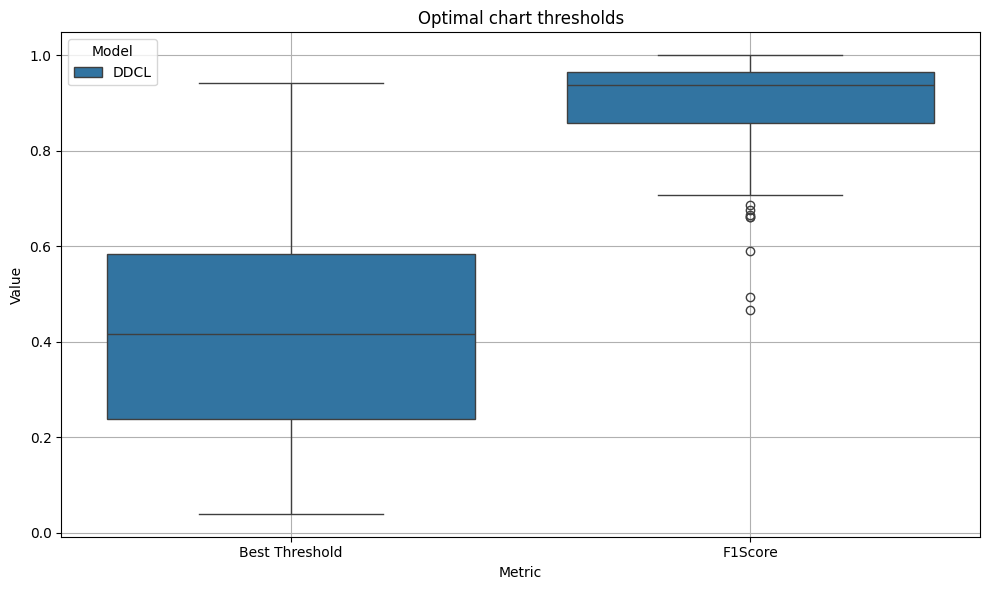

In [16]:
# List of metric dictionaries
dicts = [
    metric_dict_onset,
]

# Metric keys and their display names
metrics = ['max_thresh_coarse', 'max_f1_coarse']
metric_names = ['Best Threshold', 'F1Score']
metric_dict = dict(zip(metrics, metric_names))

# Dataset names matching the dicts
datasets_names = ['DDCL']

# Aggregate values from all models for each metric
datasets = {}
for metric in metrics:
    datasets[metric] = [sum(dct[metric].values(), []) for dct in dicts]

# Flatten data for DataFrame creation
data = {}
for metric in metrics:
    data[metric_dict[metric]] = sum(datasets[metric], [])

# Generate the model labels for each value
model_labels = []
for name, values in zip(datasets_names, datasets[metrics[0]]):
    model_labels.extend([name] * len(values))

data['Model'] = model_labels

# Create DataFrame
df = pd.DataFrame(data)

# Melt the dataframe to long-form for seaborn
df_melted = pd.melt(df, id_vars='Model', var_name='Metric', value_name='Value')

# Plot
plt.figure(figsize=(10, 6))
sns.boxplot(x='Metric', y='Value', hue='Model', data=df_melted)
plt.title('Optimal chart thresholds')
plt.grid(True)
plt.tight_layout()
plt.savefig('figs/optimal_thresh.png')
plt.show()